# The Humpback Audio Analysis

The original goal of this project is to understand how the Humpback whale calls differ from region to region and also check whether there are any differences in the way they communicate in areas with more anthropogenic noise compared to areas with less.

# Setup


In [1]:
# Some possible helper files from class

!curl -O -L -s https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/audio_utils.py
!curl -O -L -s https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py
!curl -O -L -s https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/image_utils.py
!curl -O -L -s https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/text_utils.py

# Step 1:
Importing all the required libs

In [2]:
# Some possible libraries.
# This isn't complete.

import librosa
import matplotlib.pyplot as plt
import pandas as pd
import PIL.Image as PImage
import numpy as np

from os import listdir, path

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC

from audio_utils import fft, stft
from data_utils import object_from_json_url, classification_error, display_confusion_matrix
from image_utils import get_pixels, make_image
from text_utils import get_top_words

# Step 2

I started out with connecting this repository to GIT LFS so that my heavy audio files can be stored an access online on github as well. 

Then I made sure to filter all the ocean noise from the files and tried to keep only the whale sounds as much as possible. Also normalized the volume so all the three audios are perfectly matched.

In [18]:
#Cleaning and Set up

audio_files = {
    "Caribbean": "assets/Whale_carrinbean_Sep2015.wav",
    "Australia": "assets/Whale_Queens_Aus_Aug2017.wav",
    "Santa Cruz": "assets/Whale_Santa_Cruz_Dec2016.wav"
}

clean_audio_data = {}
standard_sr = 22050

for region, file_path in audio_files.items():
    y_raw, sr = librosa.load(file_path, sr=standard_sr)
    
    y_filtered = librosa.effects.preemphasis(y_raw)    
    y_trimmed, index = librosa.effects.trim(y_filtered, top_db=20)
    y_normalized = y_trimmed / np.max(np.abs(y_trimmed))
    
    #new dictionary
    clean_audio_data[region] = y_normalized


# Step 3 
This is where it became a bit challenging. I started off with slicing the audio into 3s chunks for consitency. Once this was done I extracted frequency, measured all the points and sort of tried to calculalte the average pitch.

Then I ran MFCC which basically measures the physical shape fo the whales vocals and output in an array of 13 numbers to define the physical texture of the sound. 

In [ ]:
#Feature Extraction

extracted_regions = []
extracted_centroids = []
extracted_mfccs = []

#slicing
chunk_duration = 3.0 # seconds
samples_per_chunk = int(chunk_duration * standard_sr)



for region, y_clean in clean_audio_data.items():
    
    #slicing
    for i in range(0, len(y_clean), samples_per_chunk):
        chunk = y_clean[i : i + samples_per_chunk]
        
        
        if len(chunk) < samples_per_chunk:
            continue
            
        #Freq
        centroid = librosa.feature.spectral_centroid(y=chunk, sr=standard_sr)
        mean_centroid = np.mean(centroid) # Average 
        
        # Timbre MFCC
        mfccs = librosa.feature.mfcc(y=chunk, sr=standard_sr, n_mfcc=13)
        mean_mfccs = np.mean(mfccs.T, axis=0) # Average the 13 texture numbers
        
        #MAIN
        extracted_regions.append(region)
        extracted_centroids.append(mean_centroid)
        extracted_mfccs.append(mean_mfccs)

print(f"{len(extracted_regions)} total whale calls.")

1986 total whale calls.


# Step 4
I  took the list of regions, freq, and MFCC arrays and compiled them into a DF. 

In [16]:

mfcc_columns = [f"MFCC_{i+1}" for i in range(13)]

#Timbre DF
df_mfccs = pd.DataFrame(extracted_mfccs, columns=mfcc_columns)

#Region and Freq DF
df_main = pd.DataFrame({
    "Region": extracted_regions,
    "Frequency_Centroid": extracted_centroids
})

df = pd.concat([df_main, df_mfccs], axis=1)

print(f"\n{df.shape[0]} rows and {df.shape[1]} columns.")
print("\nFirst 5 rows:")
display(df.head())


1986 rows and 15 columns.

First 5 rows:


,Region,Frequency_Centroid,MFCC_1,MFCC_2,MFCC_3,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,MFCC_13
0,Caribbean,5049.361582,-253.781845,-41.646717,-35.746147,17.534435,-12.034196,-2.712661,-7.986603,2.278433,-2.172786,5.787648,-1.732128,8.169246,-0.024857
1,Caribbean,4694.212743,-209.618088,-50.754372,-52.749977,13.743811,-14.829150,7.907302,-10.325958,4.919339,-5.938232,8.478731,-0.074300,5.360270,-1.747029
2,Caribbean,4989.158825,-200.257690,-56.953384,-42.092129,9.160383,-24.843029,-4.800251,-18.980694,-2.775894,-8.785291,6.988511,1.778861,12.031752,5.986290
3,Caribbean,4758.838850,-200.290649,-46.875576,-44.082001,9.333500,-28.612471,-3.229829,-18.379839,-0.798969,-11.696672,2.228014,-1.419394,13.678833,9.087900
4,Caribbean,4905.127046,-206.567291,-49.783527,-36.742359,13.195971,-25.117849,-4.056950,-20.753798,-3.288668,-10.428097,3.323458,-2.043107,10.034709,4.349132


Generating 3D Timbre Cluster Map...


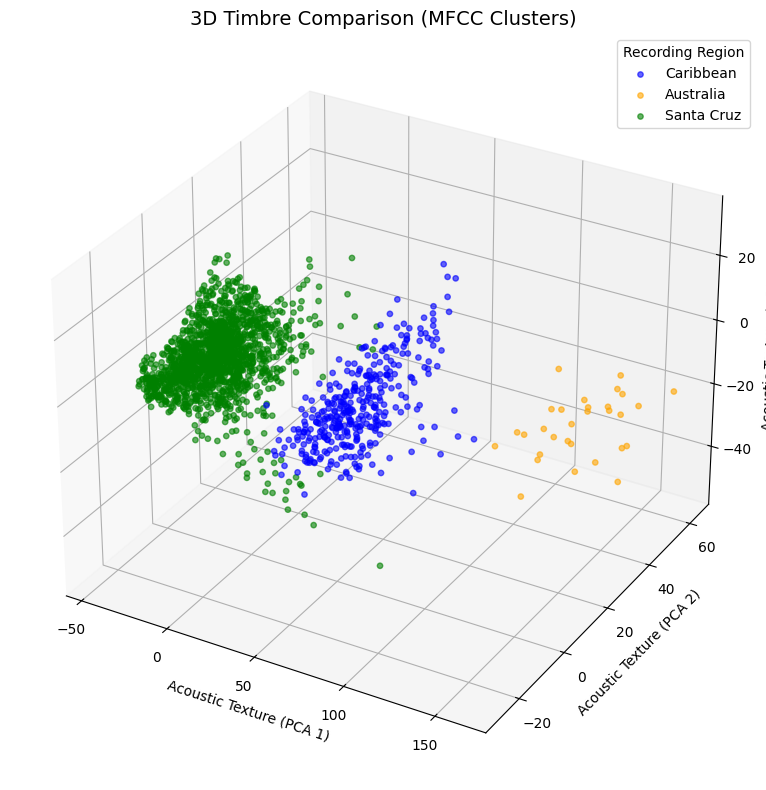

In [17]:
#PLOTTING

print("Generating 3D Timbre Cluster Map...")

# 1. Isolate the Timbre data and crush 13 dimensions down to 3
mfcc_data = df.loc[:, 'MFCC_1':'MFCC_13']
pca_3d = PCA(n_components=3)
mfcc_3d = pca_3d.fit_transform(mfcc_data)

# 2. Set up the 3D canvas
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

regions = df['Region'].unique()
colors = ['blue', 'orange', 'green']

# 3. Plot each region's cluster
for i in range(len(regions)):
    region_name = regions[i]
    
    # Find the rows for this specific region
    idx = df['Region'] == region_name
    
    # Scatter plot with X, Y, and Z coordinates
    ax.scatter(mfcc_3d[idx, 0], 
               mfcc_3d[idx, 1], 
               mfcc_3d[idx, 2], 
               c=colors[i], label=region_name, alpha=0.6, s=15)

# 4. Clean up labels and legend
ax.set_title("3D Timbre Comparison (MFCC Clusters)", fontsize=14)
ax.set_xlabel("Acoustic Texture (PCA 1)")
ax.set_ylabel("Acoustic Texture (PCA 2)")
ax.set_zlabel("Acoustic Texture (PCA 3)")
ax.legend(title="Recording Region")

plt.tight_layout()
plt.show()